# Import Library dan Dataset

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [227]:
df = pd.read_csv('dataset_2020_clean.csv')

In [228]:
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1189513,Source2,2,2020-12-28 05:55:31,2021-01-18 05:00:00,39.376530,-74.478561,NaN,NaN,0.46,...,False,False,False,False,False,False,Night,Night,Night,Day
1,A-1207989,Source2,3,2020-12-31 22:57:02,2021-01-01 00:29:02,41.932789,-88.038078,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-1207990,Source2,3,2020-12-31 22:03:27,2021-01-01 01:43:05,41.623920,-87.680061,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Night
3,A-1207991,Source2,3,2020-12-31 22:58:36,2021-01-01 01:02:45,41.794476,-87.631599,NaN,NaN,0.00,...,False,False,False,False,True,False,Night,Night,Night,Night
4,A-1208128,Source2,2,2020-12-31 23:32:07,2021-01-01 00:51:14,39.771069,-104.847038,NaN,NaN,0.00,...,False,False,False,False,True,False,Night,Night,Night,Night


In [229]:
df.shape

(1178913, 46)

In [230]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

# Data Overview

## Melihat Persebaran Kolom Target

C:\Users\claire\AppData\Local\Temp\ipykernel_17216\3993986314.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




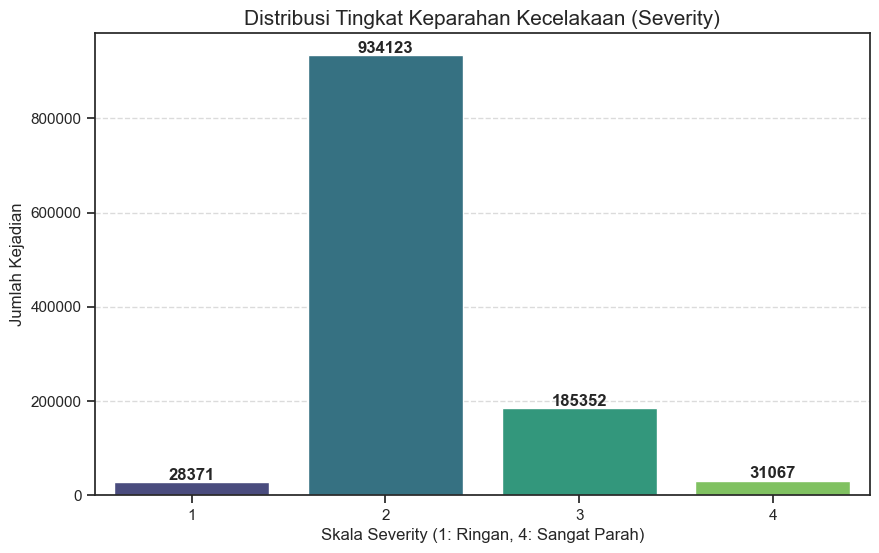

In [231]:
severity_counts = df['Severity'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=severity_counts.index, y=severity_counts.values, palette='viridis')

plt.title('Distribusi Tingkat Keparahan Kecelakaan (Severity)', fontsize=15)
plt.xlabel('Skala Severity (1: Ringan, 4: Sangat Parah)', fontsize=12)
plt.ylabel('Jumlah Kejadian', fontsize=12)

for i, v in enumerate(severity_counts.values):
    plt.text(i, v + 5000, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [232]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,1.178913e+06,1.178913e+06,1.178913e+06,708669.000000,708669.000000,1.178913e+06,1.147949e+06,1.138750e+06,1.145679e+06,1.152998e+06,1.148557e+06,1.143152e+06,1.116511e+06
mean,2.185862e+00,3.623964e+01,-9.548162e+01,36.396725,-97.404569,4.492280e-01,5.981137e+01,5.862050e+01,6.608177e+01,2.935166e+01,9.017523e+00,7.136620e+00,6.017451e-03
std,5.021481e-01,5.021891e+00,1.763442e+01,5.180773,18.517515,1.739455e+00,1.770719e+01,1.959923e+01,2.318382e+01,1.075922e+00,2.646711e+00,5.626493e+00,5.267433e-02
min,1.000000e+00,2.456309e+01,-1.244975e+02,24.574326,-124.497470,0.000000e+00,-8.900000e+01,-8.900000e+01,2.000000e+00,1.937000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.350028e+01,-1.174997e+02,33.699050,-118.104644,0.000000e+00,4.800000e+01,4.600000e+01,5.000000e+01,2.915000e+01,1.000000e+01,3.000000e+00,0.000000e+00
50%,2.000000e+00,3.580810e+01,-8.815047e+01,36.232960,-93.017730,0.000000e+00,6.100000e+01,6.100000e+01,7.000000e+01,2.966000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,3.998234e+01,-8.040440e+01,40.092670,-80.318508,2.450000e-01,7.300000e+01,7.300000e+01,8.600000e+01,2.995000e+01,1.000000e+01,1.000000e+01,0.000000e+00
max,4.000000e+00,4.899990e+01,-6.748413e+01,48.998901,-67.484130,4.417500e+02,2.030000e+02,1.890000e+02,1.000000e+02,5.804000e+01,1.200000e+02,9.840000e+02,2.400000e+01


In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178913 entries, 0 to 1178912
Data columns (total 46 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   ID                     1178913 non-null  object 
 1   Source                 1178913 non-null  object 
 2   Severity               1178913 non-null  int64  
 3   Start_Time             1178913 non-null  object 
 4   End_Time               1178913 non-null  object 
 5   Start_Lat              1178913 non-null  float64
 6   Start_Lng              1178913 non-null  float64
 7   End_Lat                708669 non-null   float64
 8   End_Lng                708669 non-null   float64
 9   Distance(mi)           1178913 non-null  float64
 10  Description            1178912 non-null  object 
 11  Street                 1178476 non-null  object 
 12  City                   1178863 non-null  object 
 13  County                 1178913 non-null  object 
 14  State             

## Missing Value

In [234]:
# Mencari jumlah missing value tiap kolom
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  470244
End_Lng                  470244
Distance(mi)                  0
Description                   1
Street                      437
City                         50
County                        0
State                         0
Zipcode                     358
Country                       0
Timezone                   1343
Airport_Code               3084
Weather_Timestamp         23759
Temperature(F)            30964
Wind_Chill(F)             40163
Humidity(%)               33234
Pressure(in)              25915
Visibility(mi)            30356
Wind_Direction            35789
Wind_Speed(mph)           35761
Precipitation(in)         62402
Weather_Condition         29974
Amenity                       0
Bump                          0
Crossing

## Nilai Unik Tiap Kolom

In [235]:
unique_counts = df.nunique().sort_values(ascending=False)

unique_df = unique_counts.reset_index()
unique_df.columns = ['Nama Kolom', 'Jumlah Nilai Unik']
print("Jumlah Nilai Unik per Kolom (Urutan Terbanyak):")
print(unique_df)

Jumlah Nilai Unik per Kolom (Urutan Terbanyak):
               Nama Kolom  Jumlah Nilai Unik
0                      ID            1178913
1                End_Time             980254
2              Start_Time             875621
3             Description             682501
4               Start_Lng             541266
5               Start_Lat             532226
6                 End_Lng             322808
7                 End_Lat             318883
8                 Zipcode             192444
9       Weather_Timestamp             145004
10                 Street             115735
11           Distance(mi)              10408
12                   City               9541
13           Airport_Code               1852
14                 County               1565
15           Pressure(in)                965
16      Precipitation(in)                175
17          Wind_Chill(F)                169
18         Temperature(F)                154
19            Humidity(%)                 99
20     

## Kesimpulan Overview

- Kolom End_Lat dan End_Lng punya jumlah missing value yang sama. Apakah missingnya di baris yang sama?
- Kolom Sunrise_Sunset - Astronomical_Twilight punya jumlah missing value yang sama. Apakah missingnya di baris yang sama? Kolom ini berisi tentang apa? Kenapa kok jumlah missingnya bisa sama?
- Kolom Pressure - Wind Speed (kolom numerikal) ada missing value
- Kolom Turning_Loop, Country nilainya hanya 1
- Kolom Weather_Condition dan Wind_Direction (kategorikal) mengandung terlalu banyak kategori
- Kolom Temperature dan Wind_Chill satuannya sama, coba di cek
- **Jangan lupa impute missing value setelah tau polanya!**

# Hasil Explore Based On Overview

## Korelasi Kolom End_Latitude dan End_Longitude

In [236]:
# Cek kolom End_Lat dan Start_Lat
df['Lat_Diff'] = abs(df['End_Lat'] - df['Start_Lat'])

correlation = df['Start_Lat'].corr(df['End_Lat'])
same_exact = (df['Start_Lat'] == df['End_Lat']).mean() * 100
print(f"Korelasi Pearson: {correlation:.6f}")


Korelasi Pearson: 0.999995


In [237]:
# Cek kolom End_Lat dan Start_Lat
df['Lng_Diff'] = abs(df['End_Lng'] - df['Start_Lng'])

correlation = df['Start_Lng'].corr(df['End_Lng'])

same_exact = (df['Start_Lng'] == df['End_Lng']).mean() * 100

print(f"Korelasi Pearson: {correlation:.6f}")


Korelasi Pearson: 0.999999


Kolom End_Lat dan End_Lng boleh di **drop** karena nilainya mirip Start_Lat dan End_Lat

## Cek 4 Kolom Terakhir

<Axes: >

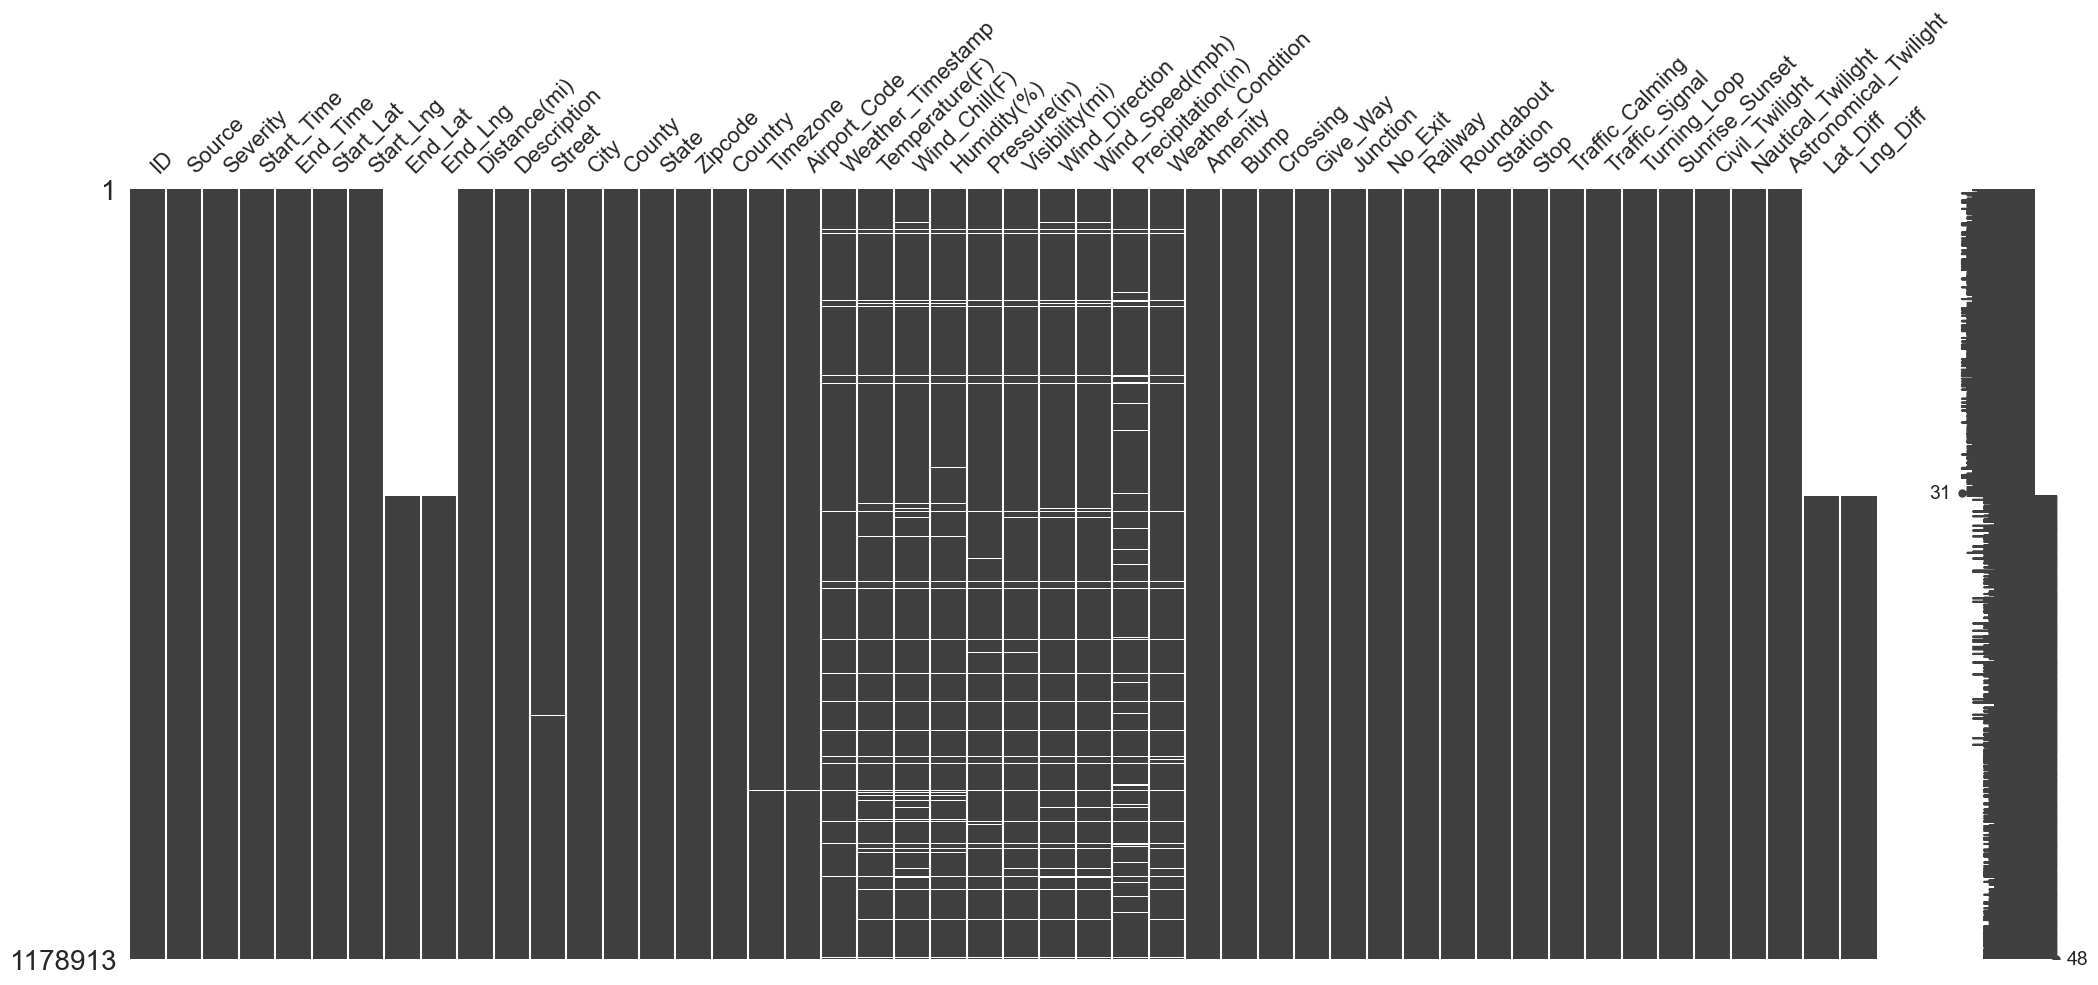

In [238]:
import missingno as msno
msno.matrix(df)

Keterangan terkait 4 kolom terakhir: 
- hilang di baris yang sama

**Penjelasan Kolom**
- Sunrise_Sunset : indikator siang dan malam (Day == matahari || Night == tidak ada matahari)
- Civil_Twilight : kondisi cahaya paling terang. momen krusial pengemudi bingung menyalakan lampu atau tidak
- Nautical_Twilight : kondisi cahaya sangat minim
- Astronomical_Twilight: langit sudah gelap total

Karena US memiliki 4 musim, kondisi langit di musim2 tertentu itu berbeda tiap jamnya. Makanya dibikin kolom seperti ini. Artinya, kolom ini **redundansi**

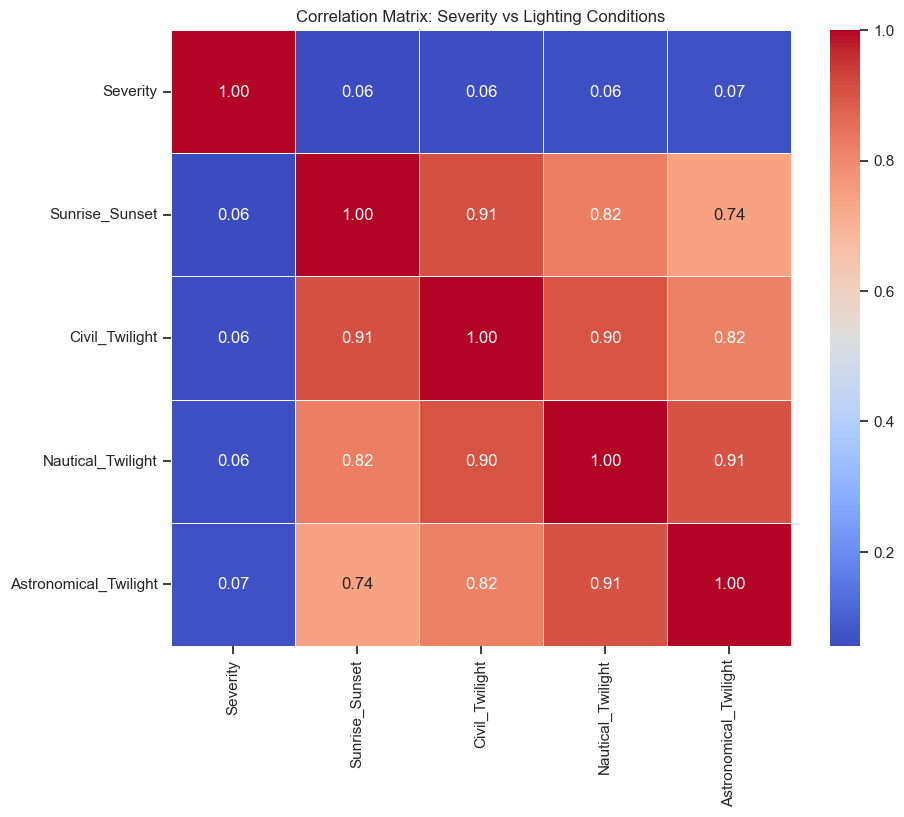

In [239]:
cols_to_analyze = ['Severity', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']
df_corr = df[cols_to_analyze].copy()

for col in cols_to_analyze[1:]:
    df_corr[col] = df_corr[col].map({'Day': 1, 'Night': 0})

correlation_matrix = df_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Severity vs Lighting Conditions')
plt.show()

Korelasi terbesar dimiliki oleh kolom Astronomical_Twilight. 
**Drop kolom lainnya**

In [240]:
df[['Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']].head()

,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,Night,Night,Night,Day
1,Night,Night,Night,Night
2,Night,Night,Night,Night
3,Night,Night,Night,Night
4,Night,Night,Night,Night


## Korelasi Pearson antara Temperature dan Wind Chill

Korelasi Pearson antara Temperature dan Wind Chill: 0.9931


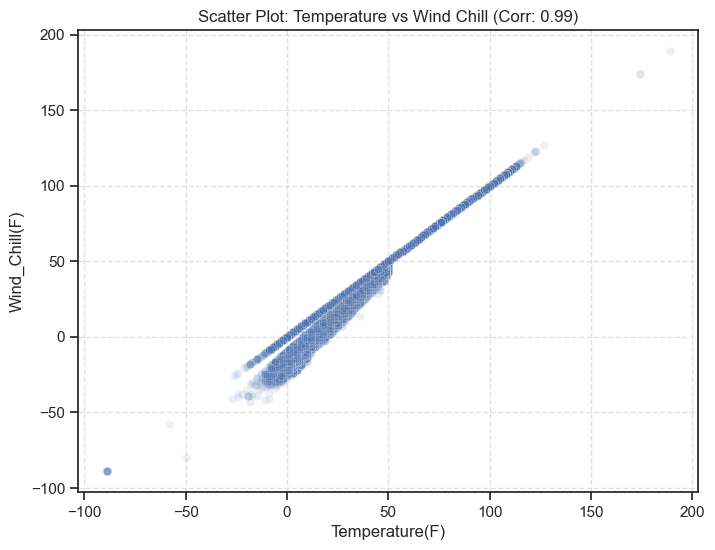

In [241]:
temp_wind_data = df[['Temperature(F)', 'Wind_Chill(F)']].dropna()

correlation = temp_wind_data['Temperature(F)'].corr(temp_wind_data['Wind_Chill(F)'])

print(f"Korelasi Pearson antara Temperature dan Wind Chill: {correlation:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Temperature(F)', y='Wind_Chill(F)', data=temp_wind_data, alpha=0.1) # alpha=0.1 karena ada 500rb baris
plt.title(f'Scatter Plot: Temperature vs Wind Chill (Corr: {correlation:.2f})')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Keputusan

- Drop kolom End_Lat, Start_Lat, End_Lng, Start_Lng, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Wind_Chill, ID, Description, Street, Zipcode, Airport_Code, Weather_Timestamp, Country, Turning_Loop, Source

# To Do List
**Setelah melihat missing value, tipe data, nilai unik, dan nama dari setiap kolom, ada beberapa to do yang harus dikerjakan:**
- Membuang kolom yang tidak penting v
- Banyak outlier ga masuk akal. Cari data trus yg dibuat jadi NaN v
- Mengubah variabel time-time jadi datetype v
- Bikin kolom hour, day, month v
- Simplify kategori kolom `Wind Direction` v
- Simplify kategori kolom `Weather_Condition` v
- Impute `Weather_Condition` based on angka numerikal v
- Impute kolom `Temperature(F)`, `Humidity(%)`, `Pressure(in)` `Visibility(mi)`, `Precipitation(in)` dan `Wind_Speed(mph)` (kolom numerikal) berdasarkan `Weather_Condition` v
- Impute kolom City based on County v 
- Impute End_Time based on severity dan duration (dari data yang ada) v
- Impute Astronomical_Twilight based on Hour, Date, + State v
- Impute Wind_Direction based on Jam + City v
- Impute Duration v

**EDA**
- Buat Geoplot dari kolom `State`

**Feature Engineering**
- Membuat kolom road_features 



# Visualisasi Data Sebelum Cleaning

## Kondisi Missing Value

In [242]:
df.isnull().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  470244
End_Lng                  470244
Distance(mi)                  0
Description                   1
Street                      437
City                         50
County                        0
State                         0
Zipcode                     358
Country                       0
Timezone                   1343
Airport_Code               3084
Weather_Timestamp         23759
Temperature(F)            30964
Wind_Chill(F)             40163
Humidity(%)               33234
Pressure(in)              25915
Visibility(mi)            30356
Wind_Direction            35789
Wind_Speed(mph)           35761
Precipitation(in)         62402
Weather_Condition         29974
Amenity                       0
Bump                          0
Crossing


Kolom yang perlu di cleaning: 
- City
- Temperature(F)           
- Humidity(%)             
- Pressure(in)           
- Visibility(mi)          
- Wind_Direction          
- Wind_Speed(mph)         
- Precipitation(in)      
- Weather_Condition    
- Astronomical Twilight   

Gimana cara impute mereka?


## Persebaran Data

C:\Users\claire\AppData\Local\Temp\ipykernel_17216\1291221251.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\claire\AppData\Local\Temp\ipykernel_17216\1291221251.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\claire\AppData\Local\Temp\ipykernel_17216\1291221251.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\claire\AppData\Local\Temp\ipykernel_17216\1291221251.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the

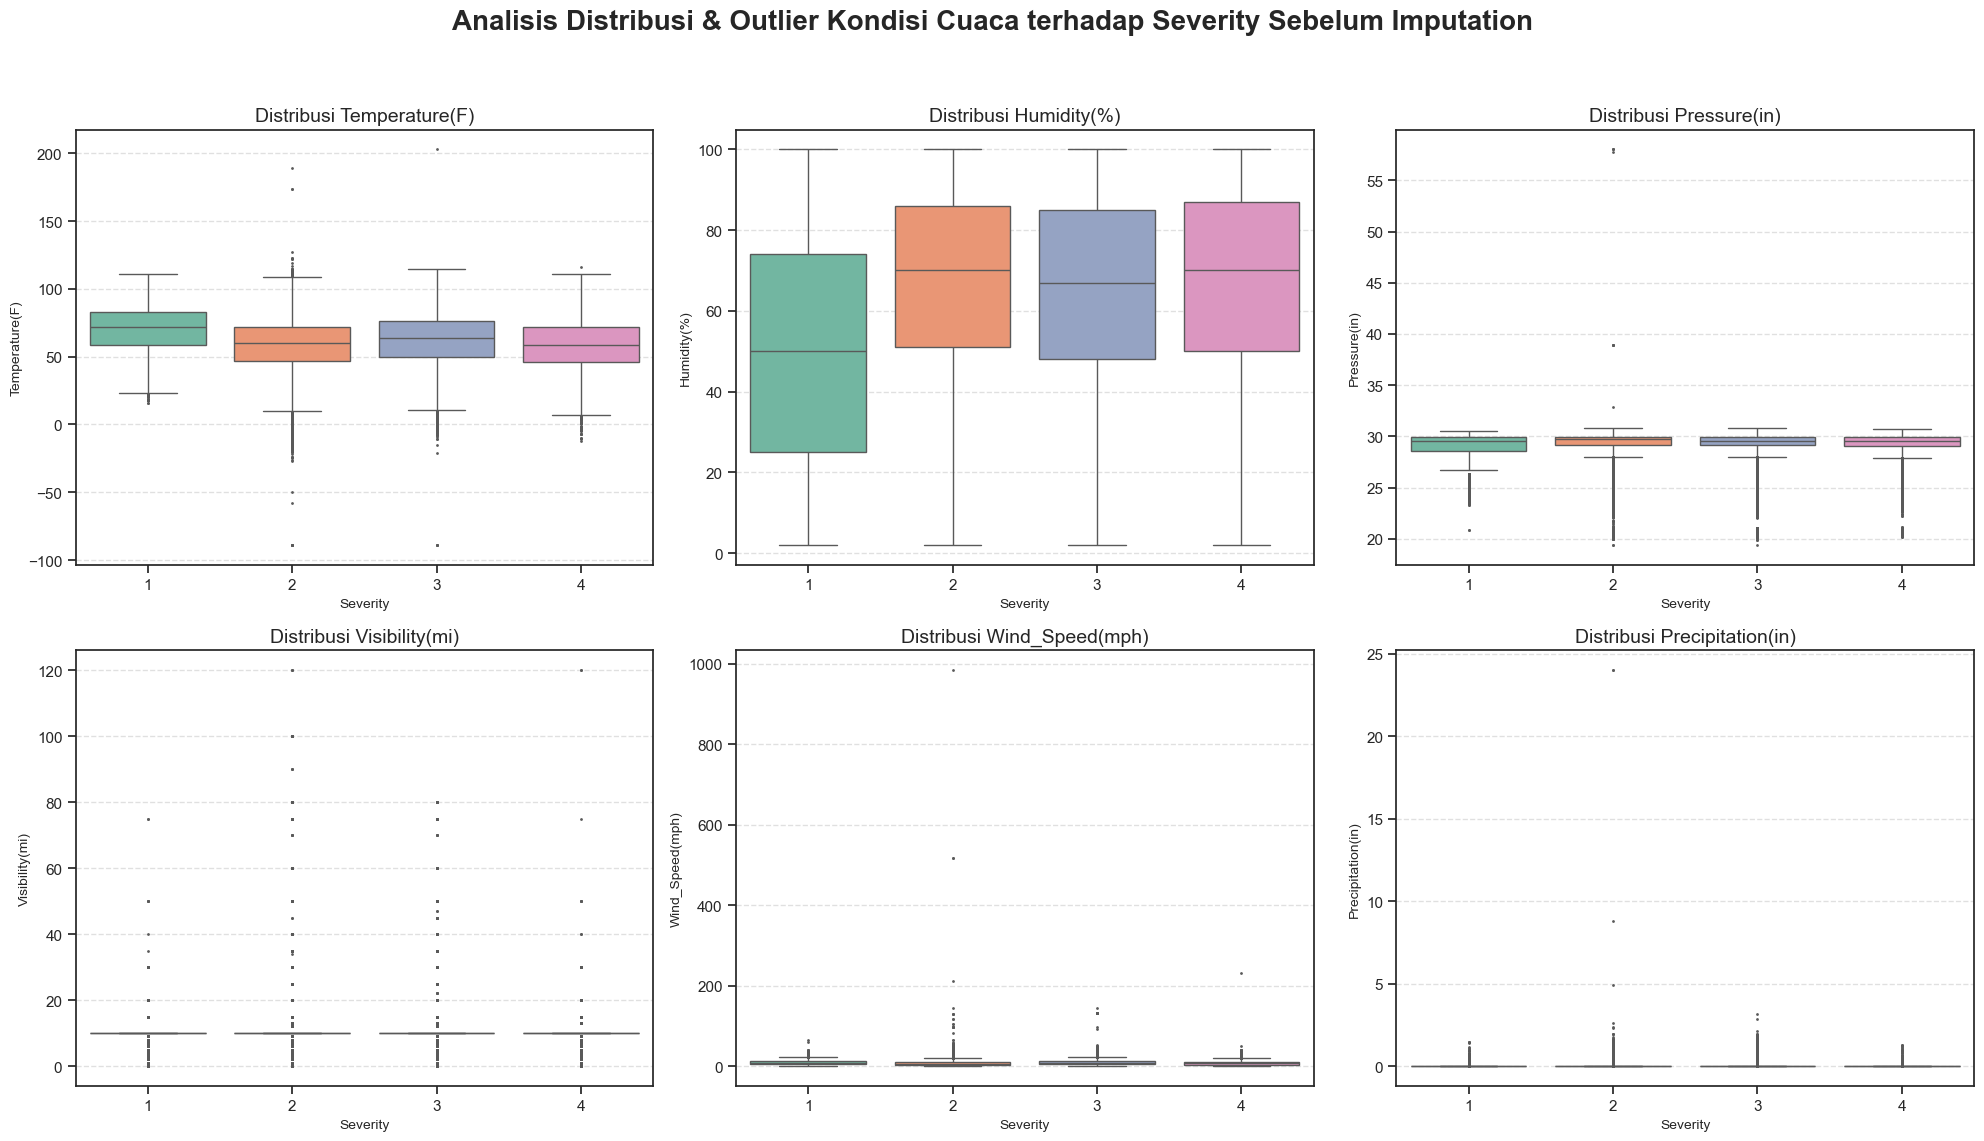

In [243]:
weather_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

sns.set_theme(style="ticks")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
fig.suptitle('Analisis Distribusi & Outlier Kondisi Cuaca terhadap Severity Sebelum Imputation', fontsize=20, fontweight='bold')

for i, col in enumerate(weather_cols):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)

    ax.set_title(f'Distribusi {col}', fontsize=14)
    ax.set_xlabel('Severity', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Jumlah Baris dengan Nilai yang Tidak Wajar

In [244]:
invalid_mask = (
    (df['Temperature(F)'] < -42) | (df['Temperature(F)'] > 130) |
    (df['Humidity(%)'] < 5) | (df['Humidity(%)'] > 100) |
    (df['Pressure(in)'] < 27.2) | (df['Pressure(in)'] > 31.3) |
    (df['Visibility(mi)'] < 0) | (df['Visibility(mi)'] > 130) |
    (df['Wind_Speed(mph)'] < 0) | (df['Wind_Speed(mph)'] > 190) |
    (df['Precipitation(in)'] < 0) | (df['Precipitation(in)'] > 16.7)
)

total_invalid = invalid_mask.sum()

print(f"Total baris dengan data cuaca tidak wajar: {total_invalid}")

Total baris dengan data cuaca tidak wajar: 60481


## Korelasi Pearson antar Fitur

In [245]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
correlations = df.select_dtypes(include=[np.number]).corr()['Severity'].sort_values(ascending=False)
print("Korelasi Fitur terhadap Severity di Awal:")
print(correlations)

Korelasi Fitur terhadap Severity di Awal:
Severity             1.000000
End_Lng              0.140340
Start_Lng            0.122403
End_Lat              0.101578
Distance(mi)         0.100393
Lng_Diff             0.084135
Lat_Diff             0.075969
Start_Lat            0.074482
Wind_Speed(mph)      0.046215
Junction             0.031613
Precipitation(in)    0.028273
Humidity(%)          0.022308
Temperature(F)       0.010252
Wind_Chill(F)        0.004667
Traffic_Calming      0.001406
Bump                -0.000674
Roundabout          -0.001639
Give_Way            -0.005675
No_Exit             -0.007931
Railway             -0.012659
Pressure(in)        -0.013124
Visibility(mi)      -0.017271
Amenity             -0.020518
Station             -0.034228
Stop                -0.036607
Crossing            -0.111245
Traffic_Signal      -0.117975
Turning_Loop              NaN
Name: Severity, dtype: float64


# Data Cleaning

## Membuang Kolom Redundant dan Useless

In [246]:
# Hapus kolom tidak penting
cols_to_drop = [
    'End_Lat', 'End_Lng', 'Start_Lat', 'Start_Lng', 'Sunrise_Sunset', 'Civil_Twilight', 
    'Nautical_Twilight', 'Wind_Chill(F)', 'ID', 'Description', 
    'Street', 'Zipcode', 'Airport_Code', 'Weather_Timestamp', 
    'Country', 'Turning_Loop', 'Source', 'Lat_Diff', 'Lng_Diff', 'Timezone'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

Kolom yang di drop adalah kolom-kolom yang **redundant dan tidak berguna untuk model**

**Melalui visualisasi tersebut, dapat dilihat bahwa:**
- Semua kolom memiliki outlier yang tidak wajar, kecuali kolom Humidity. Kita bisa mempertimbangkan untuk impute dengam metode groupby Weather_Condition dengan median

## Mengubah Nilai Aneh jadi NaN

Data diubah jadi NaN agar data bisa diimputasi dengan nilai yang sesuai weather conditionnya

In [247]:
weather_cols = [
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

In [248]:
df[weather_cols].isnull().sum()

Temperature(F)       30964
Humidity(%)          33234
Pressure(in)         25915
Visibility(mi)       30356
Wind_Speed(mph)      35761
Precipitation(in)    62402
dtype: int64

In [249]:
df.loc[(df['Temperature(F)'] < -42) | (df['Temperature(F)'] > 130), 'Temperature(F)'] = np.nan
df.loc[(df['Humidity(%)'] < 5) | (df['Humidity(%)'] > 100), 'Humidity(%)'] = np.nan
df.loc[(df['Pressure(in)'] < 27.2) | (df['Pressure(in)'] > 31.3), 'Pressure(in)'] = np.nan
df.loc[(df['Visibility(mi)'] < 0) | (df['Visibility(mi)'] > 130), 'Visibility(mi)'] = np.nan
df.loc[(df['Wind_Speed(mph)'] < 0) | (df['Wind_Speed(mph)'] > 190), 'Wind_Speed(mph)'] = np.nan
df.loc[(df['Precipitation(in)'] < 0) | (df['Precipitation(in)'] > 16.7), 'Precipitation(in)'] = np.nan

In [250]:
df[weather_cols].isnull().sum()

Temperature(F)       30980
Humidity(%)          33501
Pressure(in)         86204
Visibility(mi)       30356
Wind_Speed(mph)      35766
Precipitation(in)    62404
dtype: int64

## Mengubah ke Datetype

In [251]:
cols_to_fix = ['Start_Time', 'End_Time']

for col in cols_to_fix:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(df[cols_to_fix].dtypes)
df[cols_to_fix].head()

Start_Time    datetime64[ns]
End_Time      datetime64[ns]
dtype: object


,Start_Time,End_Time
0,2020-12-28 05:55:31,2021-01-18 05:00:00
1,2020-12-31 22:57:02,2021-01-01 00:29:02
2,2020-12-31 22:03:27,2021-01-01 01:43:05
3,2020-12-31 22:58:36,2021-01-01 01:02:45
4,2020-12-31 23:32:07,2021-01-01 00:51:14


## Buat Kolom Hour, Day, Month

In [252]:
df['Hour'] = df['Start_Time'].dt.hour
df['Month'] = df['Start_Time'].dt.month
df['Day'] = df['Start_Time'].dt.dayofweek

## Simplifikasi Kolom Wind_Direction

In [253]:
df.loc[df['Wind_Direction']=='Calm','Wind_Direction'] = 'CALM'
df.loc[(df['Wind_Direction']=='West')|(df['Wind_Direction']=='WSW')|(df['Wind_Direction']=='WNW'),'Wind_Direction'] = 'W'
df.loc[(df['Wind_Direction']=='South')|(df['Wind_Direction']=='SSW')|(df['Wind_Direction']=='SSE'),'Wind_Direction'] = 'S'
df.loc[(df['Wind_Direction']=='North')|(df['Wind_Direction']=='NNW')|(df['Wind_Direction']=='NNE'),'Wind_Direction'] = 'N'
df.loc[(df['Wind_Direction']=='East')|(df['Wind_Direction']=='ESE')|(df['Wind_Direction']=='ENE'),'Wind_Direction'] = 'E'
df.loc[df['Wind_Direction']=='Variable','Wind_Direction'] = 'VAR'

print("Wind Direction after simplification: ", df['Wind_Direction'].unique())
print('Jumlah nilai unik Wind Direction:', df.Wind_Direction.nunique())

Wind Direction after simplification:  ['S' 'CALM' 'E' 'SE' 'W' 'NW' 'N' 'SW' 'VAR' nan 'NE']
Jumlah nilai unik Wind Direction: 10


## Simplifikasi Kolom Weather_Condition

In [254]:
# Cari tau kategori di Weather_Condition
df.Weather_Condition.unique()

array(['Fair', 'Mostly Cloudy', 'Cloudy', 'Light Rain',
       'Light Rain / Windy', 'Light Snow', 'Partly Cloudy', 'Rain',
       'Haze', nan, 'Wintry Mix', 'Fog', 'Light Drizzle', 'Heavy Rain',
       'T-Storm', 'Fair / Windy', 'Drizzle and Fog',
       'Partly Cloudy / Windy', 'Light Rain with Thunder', 'Rain / Windy',
       'Heavy T-Storm', 'Cloudy / Windy', 'Heavy Rain / Windy',
       'Light Freezing Rain', 'Mist', 'Snow', 'Light Freezing Drizzle',
       'Drizzle', 'N/A Precipitation', 'Mostly Cloudy / Windy',
       'Wintry Mix / Windy', 'Light Snow / Windy', 'Heavy Snow',
       'Patches of Fog', 'Showers in the Vicinity', 'Shallow Fog',
       'Thunder', 'Snow / Windy', 'Heavy Snow / Windy', 'T-Storm / Windy',
       'Fog / Windy', 'Haze / Windy', 'Heavy T-Storm / Windy',
       'Thunder in the Vicinity', 'Snow and Sleet / Windy',
       'Blowing Snow / Windy', 'Blowing Snow', 'Light Snow and Sleet',
       'Light Sleet', 'Smoke', 'Heavy Drizzle', 'Thunder / Windy',
       '

In [255]:
conditions = [
    # 1. HAIL & SLEET: Paling spesifik dan ekstrem
    df['Weather_Condition'].str.contains('hail|sleet', case=False, na=False),
    
    # 2. THUNDERSTORM: Badai dan petir
    df['Weather_Condition'].str.contains('thunder|t-storm|squalls', case=False, na=False),
    
    # 3. SNOW: Salju dan kondisi beku (Wintry Mix masuk sini)
    df['Weather_Condition'].str.contains('snow|wintry|freezing|blizzard', case=False, na=False),
    
    # 4. RAIN: Semua jenis hujan dan gerimis
    df['Weather_Condition'].str.contains('rain|drizzle|shower|precipitation', case=False, na=False),
    
    # 5. FOG: Kabut, asap, dan debu
    df['Weather_Condition'].str.contains('fog|haze|mist|smoke|dust|sand|patches', case=False, na=False),
    
    # 6. CLEAR/CLOUDY: Cerah atau mendung tanpa presipitasi
    df['Weather_Condition'].str.contains('fair|cloudy|clear|overcast', case=False, na=False)
]

choices = ['hail', 'thunderstorm', 'snow', 'rain', 'fog', 'clear']

df['Weather_Condition'] = np.select(conditions, choices, default='other')

print("Distribusi Hasil Simplifikasi:")
print(df['Weather_Condition'].value_counts())

Distribusi Hasil Simplifikasi:
Weather_Condition
clear           985581
rain             92847
fog              40111
other            29974
snow             19747
thunderstorm     10558
hail                95
Name: count, dtype: int64


## Impute Kolom Numerical 
Kolom numerical diimputasi menggunakan median per City dan Month. Jika menggunakan Weather_Condition, kemungkinan hasil imputasi akan error. Hal ini dikarenakan label cuaca itu subjektif dan terlalu luas, sedangkan lokasi dan waktu itu absolut.

Label Weather_Condition seperti "Fair" (Cerah) punya arti suhu yang sangat berbeda di tempat yang berbeda.
- Kasus A: Di Miami, Florida saat bulan Januari, cuaca "Fair" suhunya bisa 75°F.
- Kasus B: Di Minneapolis, Minnesota saat bulan Januari, cuaca "Fair" suhunya bisa -5°F.

In [256]:
for col in weather_cols:
    df[col] = df[col].fillna(df.groupby(['City', 'Month'])[col].transform('median'))
    df[col] = df[col].fillna(df.groupby(['State', 'Month'])[col].transform('median'))
    df[col] = df[col].fillna(df.groupby('Month')[col].transform('median'))

df[weather_cols].isnull().sum()

Temperature(F)       0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Speed(mph)      0
Precipitation(in)    0
dtype: int64

## Impute Weather Condition

In [257]:
df.loc[(df['Weather_Condition'].isna()) & (df['Precipitation(in)'] > 0) & (df['Temperature(F)'] <= 32), 'Weather_Condition'] = 'Snow'
df.loc[(df['Weather_Condition'].isna()) & (df['Precipitation(in)'] > 0) & (df['Temperature(F)'] > 32), 'Weather_Condition'] = 'Rain'
df.loc[(df['Weather_Condition'].isna()) & (df['Visibility(mi)'] < 1), 'Weather_Condition'] = 'Fog'

df['Weather_Condition'] = df['Weather_Condition'].fillna(
    df.groupby(['City', 'Month'])['Weather_Condition'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

df['Weather_Condition'] = df['Weather_Condition'].fillna(
    df.groupby(['State', 'Month'])['Weather_Condition'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Clear")
)

In [258]:
df.Weather_Condition.isnull().sum()

np.int64(0)

## Impute City based on Modus di County

In [259]:
# Impute kolom City based on modus di County
df['City'] = df.groupby('County')['City'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown City")
)
df['City'] = df['City'].fillna("Unknown City")

## Impute End_Time

In [260]:
# Bikin kolom duration untuk mengetahui seberapa lama traffic menyebabkan kemacetan
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

In [261]:
# Impute End_Time
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
mean_duration = df.groupby('Severity')['Duration'].transform('mean')

mask = df['End_Time'].isna()
df.loc[mask, 'End_Time'] = df.loc[mask, 'Start_Time'] + pd.to_timedelta(mean_duration[mask], unit='m')

In [262]:
df['Duration'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60

## Impute Astronomical_Twilight

In [263]:
def get_mode(x):
    m = x.mode()
    return m.iloc[0] if not m.empty else np.nan

fallback_levels = [
    ['State', 'Month', 'Hour'],
    ['Month', 'Hour'],
    ['Hour']
]

for level in fallback_levels:
    df['Astronomical_Twilight'] = df['Astronomical_Twilight'].fillna(
        df.groupby(level)['Astronomical_Twilight'].transform(get_mode)
    )


In [264]:
df.Astronomical_Twilight.isnull().sum()

np.int64(0)

## Impute Wind_Direction

In [265]:
# Impute kolom Wind_Direction based on City dan Month
df['Wind_Direction'] = df['Wind_Direction'].fillna(
    df.groupby(['City', 'Month'])['Wind_Direction'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
)

df['Wind_Direction'] = df['Wind_Direction'].fillna(
    df.groupby(['State', 'Month'])['Wind_Direction'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else np.nan
    )
)

global_mode = df['Wind_Direction'].mode()[0]
df['Wind_Direction'] = df['Wind_Direction'].fillna(global_mode)

In [266]:
df.Wind_Direction.isnull().sum()

np.int64(0)

## Cek Missing Semua Kolom

In [267]:
df.isnull().sum()  

Severity                 0
Start_Time               0
End_Time                 0
Distance(mi)             0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Astronomical_Twilight    0
Hour                     0
Month                    0
Day                      0
Duration                 0
dtype: int64

## Membuat Road_Features

In [268]:
# Membuat kolom road_features
road_features = [
    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal"
]

df["Road_Features"] = df[road_features].sum(axis=1)

# Visualisasi Data Setelah di Impute

## Persebaran Data

C:\Users\claire\AppData\Local\Temp\ipykernel_17216\1836399321.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\claire\AppData\Local\Temp\ipykernel_17216\1836399321.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\claire\AppData\Local\Temp\ipykernel_17216\1836399321.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\claire\AppData\Local\Temp\ipykernel_17216\1836399321.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the

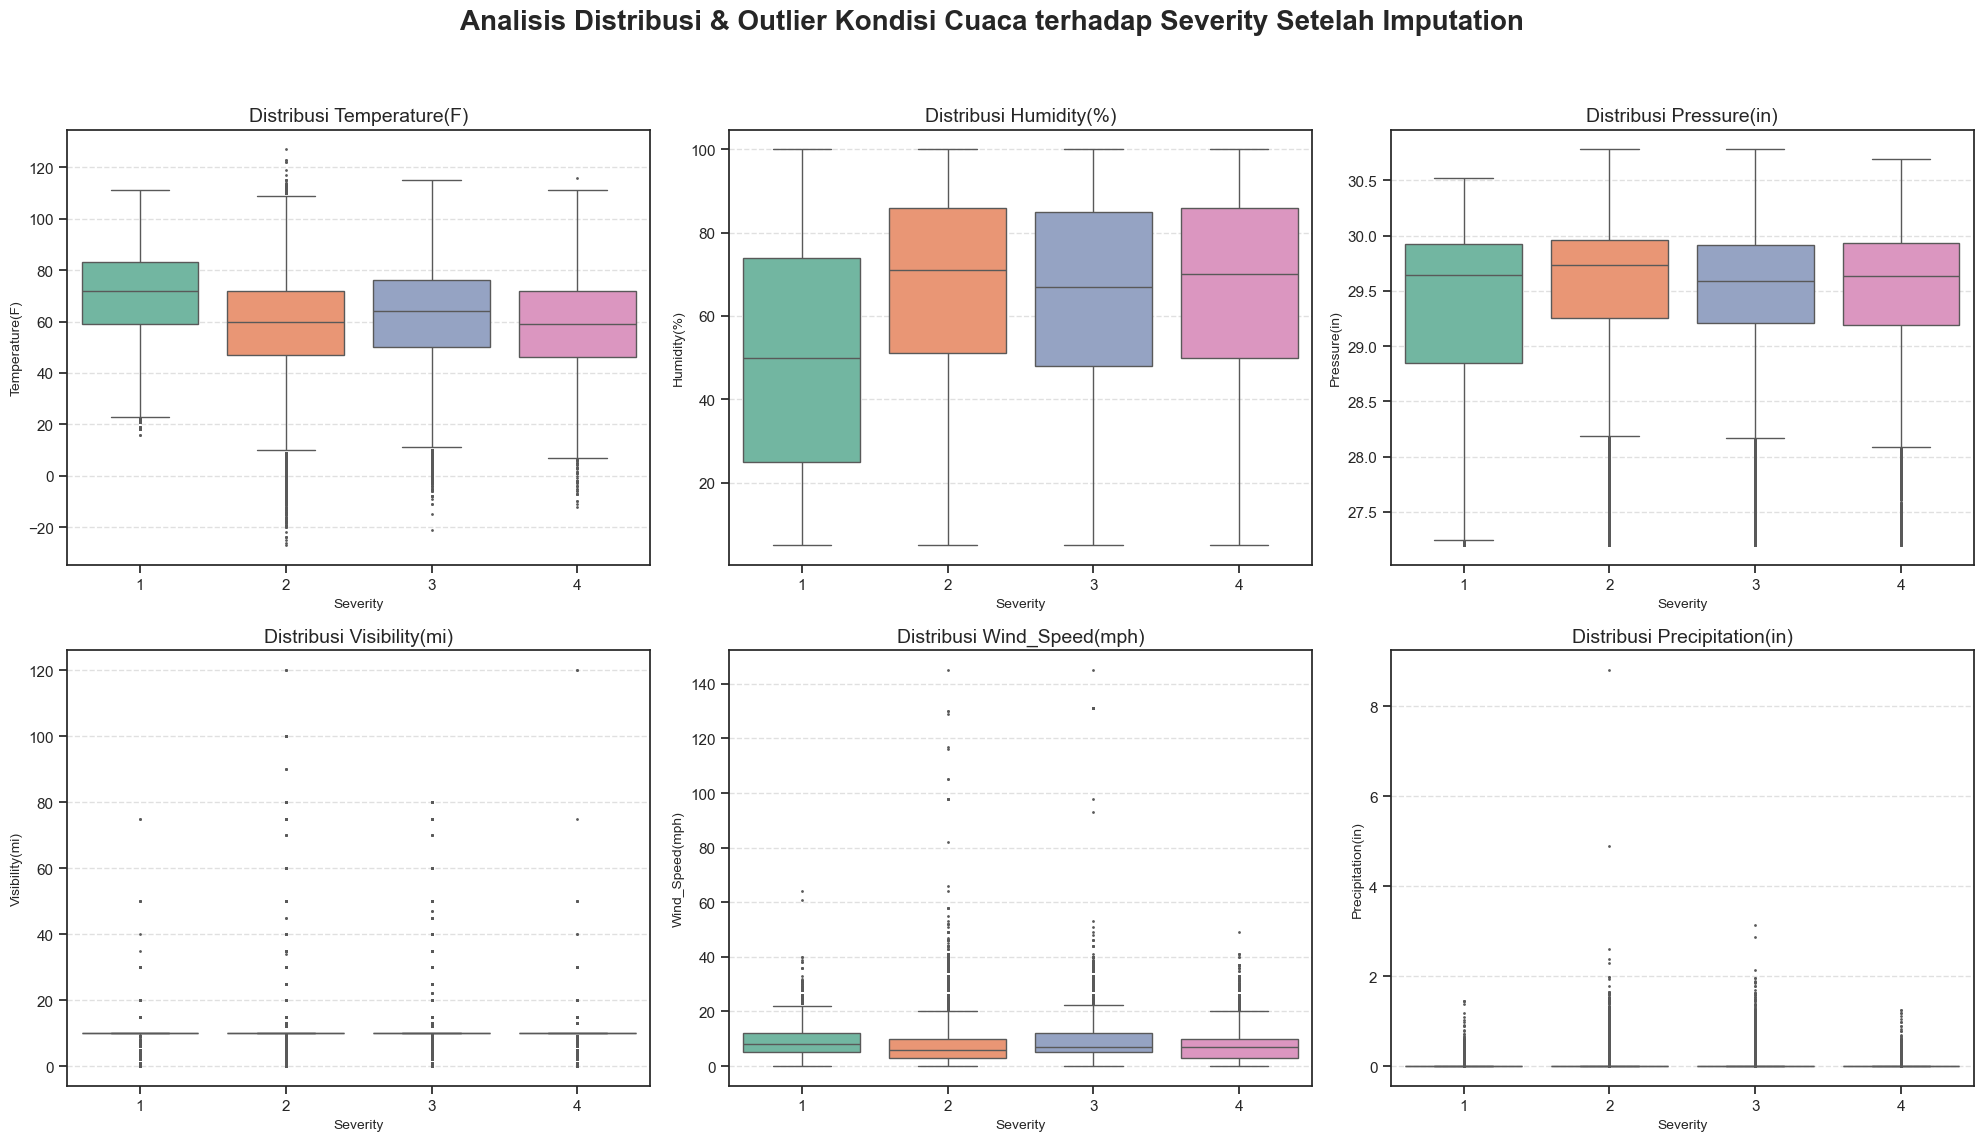

In [269]:
# Visualisasi distribusi data di kolom numerikal
sns.set_theme(style="ticks")

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
fig.suptitle('Analisis Distribusi & Outlier Kondisi Cuaca terhadap Severity Setelah Imputation', fontsize=20, fontweight='bold')

for i, col in enumerate(weather_cols):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    
    sns.boxplot(data=df, x='Severity', y=col, ax=ax, palette='Set2', fliersize=1)

    ax.set_title(f'Distribusi {col}', fontsize=14)
    ax.set_xlabel('Severity', fontsize=10)
    ax.set_ylabel(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [270]:
df = df.drop(columns='Timezone', errors='ignore')

## Missing Value

In [271]:
df.isnull().sum()

Severity                 0
Start_Time               0
End_Time                 0
Distance(mi)             0
City                     0
County                   0
State                    0
Temperature(F)           0
Humidity(%)              0
Pressure(in)             0
Visibility(mi)           0
Wind_Direction           0
Wind_Speed(mph)          0
Precipitation(in)        0
Weather_Condition        0
Amenity                  0
Bump                     0
Crossing                 0
Give_Way                 0
Junction                 0
No_Exit                  0
Railway                  0
Roundabout               0
Station                  0
Stop                     0
Traffic_Calming          0
Traffic_Signal           0
Astronomical_Twilight    0
Hour                     0
Month                    0
Day                      0
Duration                 0
Road_Features            0
dtype: int64

In [272]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)
correlations = df.select_dtypes(include=[np.number]).corr()['Severity'].sort_values(ascending=False)
print("Korelasi Fitur terhadap Severity di Akhir:")
print(correlations)

Korelasi Fitur terhadap Severity di Akhir:
Severity             1.000000
Distance(mi)         0.100393
Wind_Speed(mph)      0.046976
Precipitation(in)    0.036159
Junction             0.031613
Hour                 0.029040
Day                  0.024540
Humidity(%)          0.021584
Temperature(F)       0.011918
Pressure(in)         0.008506
Traffic_Calming      0.001406
Duration            -0.000358
Bump                -0.000674
Roundabout          -0.001639
Give_Way            -0.005675
No_Exit             -0.007931
Railway             -0.012659
Visibility(mi)      -0.017045
Amenity             -0.020518
Station             -0.034228
Stop                -0.036607
Month               -0.095685
Crossing            -0.111245
Road_Features       -0.116210
Traffic_Signal      -0.117975
Name: Severity, dtype: float64


In [273]:
df.shape

(1178913, 33)

In [274]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Distance(mi)', 'City', 'County',
       'State', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Astronomical_Twilight',
       'Hour', 'Month', 'Day', 'Duration', 'Road_Features'],
      dtype='object')

# EDA 
Dilakukan setelah semua data rapi dan bagus

## State dengan Jumlah Terbanyak

In [275]:
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Total_Accidents']

fig = px.choropleth(state_counts, 
                    locations='State', 
                    locationmode="USA-states", 
                    color='Total_Accidents',
                    scope="usa",
                    color_continuous_scale="Reds",
                    title='Total Kecelakaan Lalu Lintas per Negara Bagian (USA)')

fig.show()

In [276]:
df.State.value_counts()

State
CA    285532
FL    130362
TX     73488
SC     62789
NY     48805
NC     48633
VA     44803
PA     43189
MN     39193
OR     34452
AZ     29535
TN     28463
LA     26342
IL     25007
MD     24351
GA     23427
AL     20185
NJ     18590
OH     17240
UT     16192
MI     15763
CO     13889
OK     13590
WA     13211
MA     11101
MO     10372
CT      9341
IN      7806
KY      5568
WI      3933
IA      3649
AR      3090
KS      2644
DC      2632
NE      2493
DE      2478
MT      2450
NV      2442
RI      2387
ID      2319
MS      2019
NH      1496
NM      1436
WV      1171
ND       399
ME       281
VT       186
SD       160
WY        29
Name: count, dtype: int64

## State dengan Severity Tertinggi

In [277]:
# Cari tau state dengan rata2 severity tertinggi 
state_severity = df.groupby('State')['Severity'].mean().reset_index()

state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Accident_Count']

map_data = pd.merge(state_severity, state_counts, on='State')

print(map_data.sort_values(by='Severity', ascending=False).head())

   State  Severity  Accident_Count
48    WY  3.275862              29
12    IL  2.611909           25007
46    WI  2.575896            3933
13    IN  2.545478            7806
22    MO  2.528153           10372


In [278]:
fig = px.choropleth(
    map_data, 
    locations='State',            
    locationmode="USA-states",    
    color='Severity',             
    hover_name='State',           
    hover_data=['Accident_Count'],
    color_continuous_scale="Reds",
    scope="usa",                  
    title='Rata-rata Severity Kecelakaan per Negara Bagian'
)

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

## Distribusi Kecelakaan berdasarkan Waktu

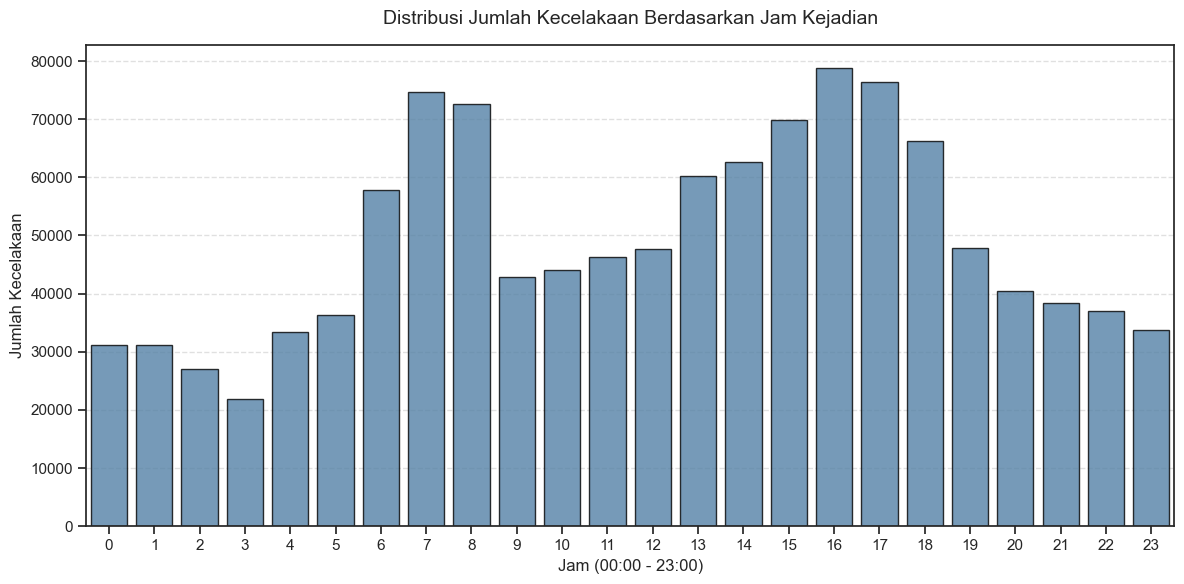

In [279]:
# Distribusi Kecelakaan berdasarkan Waktu
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x="Hour", color="steelblue", edgecolor="black", alpha=0.8)

plt.title("Distribusi Jumlah Kecelakaan Berdasarkan Jam Kejadian", fontsize=14, pad=15)
plt.xlabel("Jam (00:00 - 23:00)", fontsize=12)
plt.ylabel("Jumlah Kecelakaan", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Distribusi Kecelakaan berdasarkan Weather_Condition

C:\Users\claire\AppData\Local\Temp\ipykernel_17216\2063745407.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




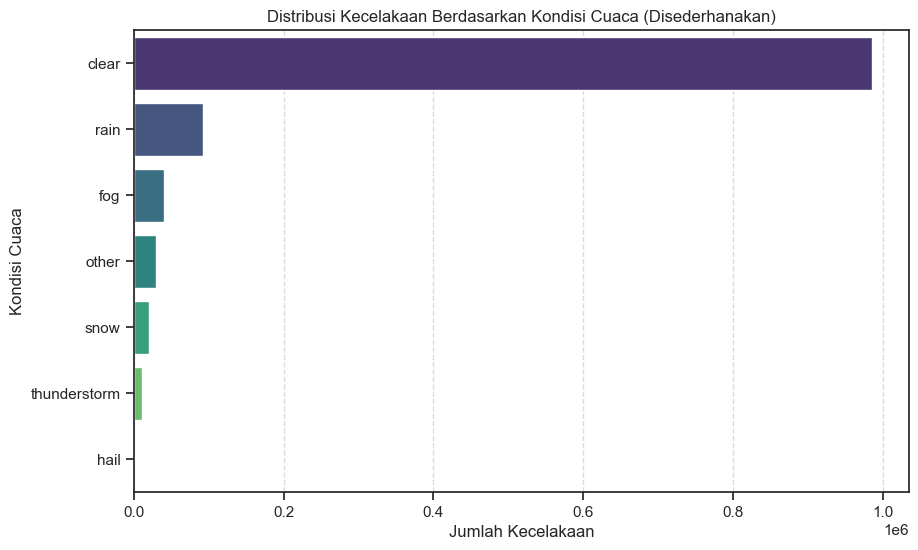

In [280]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Weather_Condition', order=df['Weather_Condition'].value_counts().index, palette='viridis')
plt.title('Distribusi Kecelakaan Berdasarkan Kondisi Cuaca (Disederhanakan)')
plt.xlabel('Jumlah Kecelakaan')
plt.ylabel('Kondisi Cuaca')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

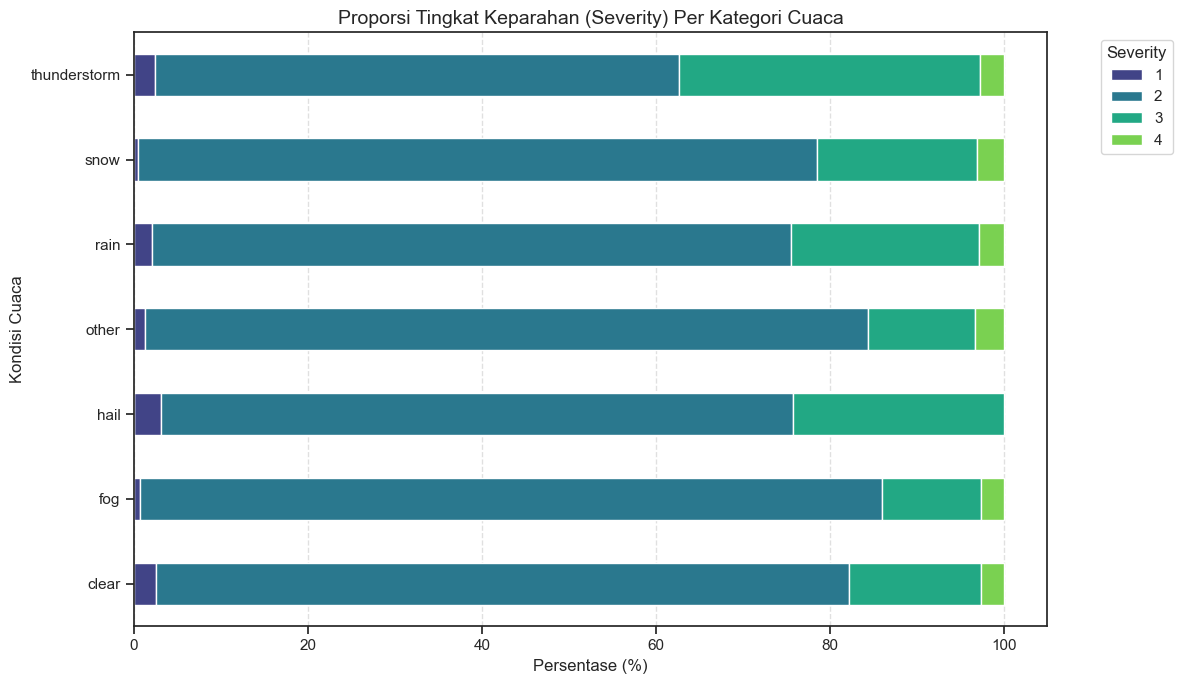

In [281]:
weather_severity_cross = pd.crosstab(df['Weather_Condition'], df['Severity'])

weather_severity_pct = weather_severity_cross.div(weather_severity_cross.sum(1), axis=0) * 100

weather_severity_pct.plot(kind='barh', stacked=True, figsize=(12, 7), 
                          color=sns.color_palette("viridis", 4))

plt.title('Proporsi Tingkat Keparahan (Severity) Per Kategori Cuaca', fontsize=14)
plt.xlabel('Persentase (%)')
plt.ylabel('Kondisi Cuaca')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

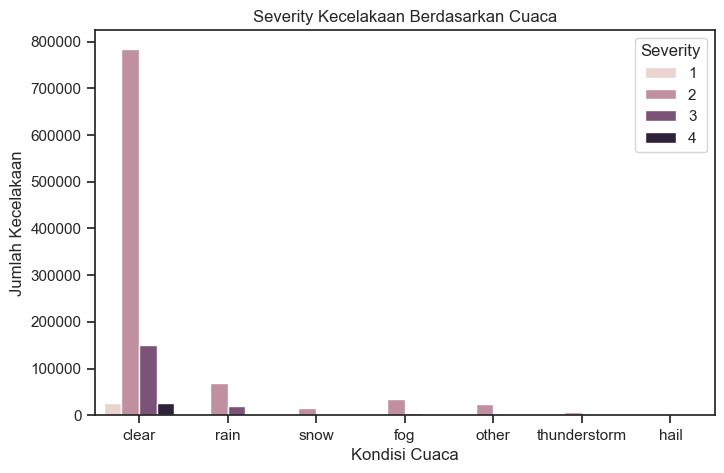

In [282]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Weather_Condition", hue="Severity")

plt.title("Severity Kecelakaan Berdasarkan Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Jumlah Kecelakaan")

plt.show()

## Distribusi Kecelakaan tiap Bulan

C:\Users\claire\AppData\Local\Temp\ipykernel_17216\4283050729.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




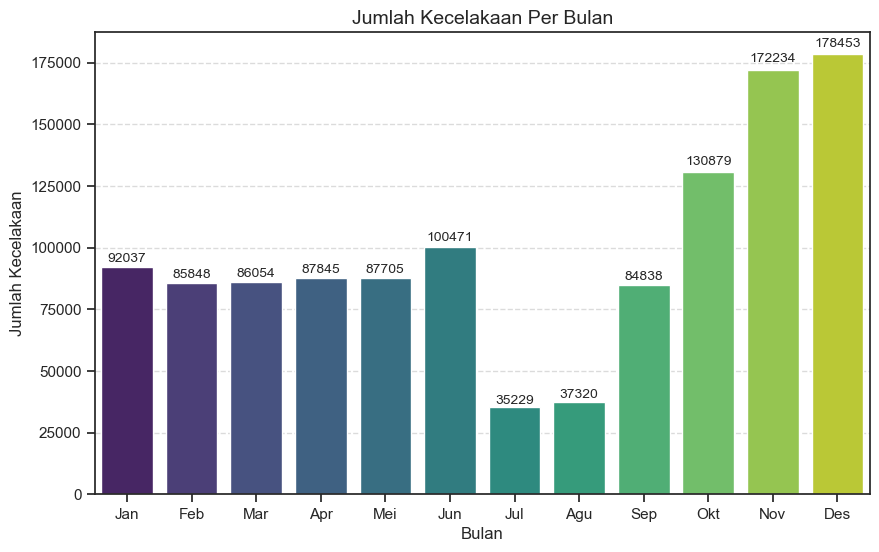

In [283]:
# Distribusi per Bulan
monthly_counts = df['Month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
plt.figure(figsize=(10, 6))
sns.barplot(x=month_names, y=monthly_counts.values, palette='viridis')

plt.title('Jumlah Kecelakaan Per Bulan', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Kecelakaan', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, val in enumerate(monthly_counts.values):
    plt.text(i, val + (val*0.01), f'{int(val)}', ha='center', va='bottom', fontsize=10)

plt.show()

C:\Users\claire\AppData\Local\Temp\ipykernel_17216\2639928508.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




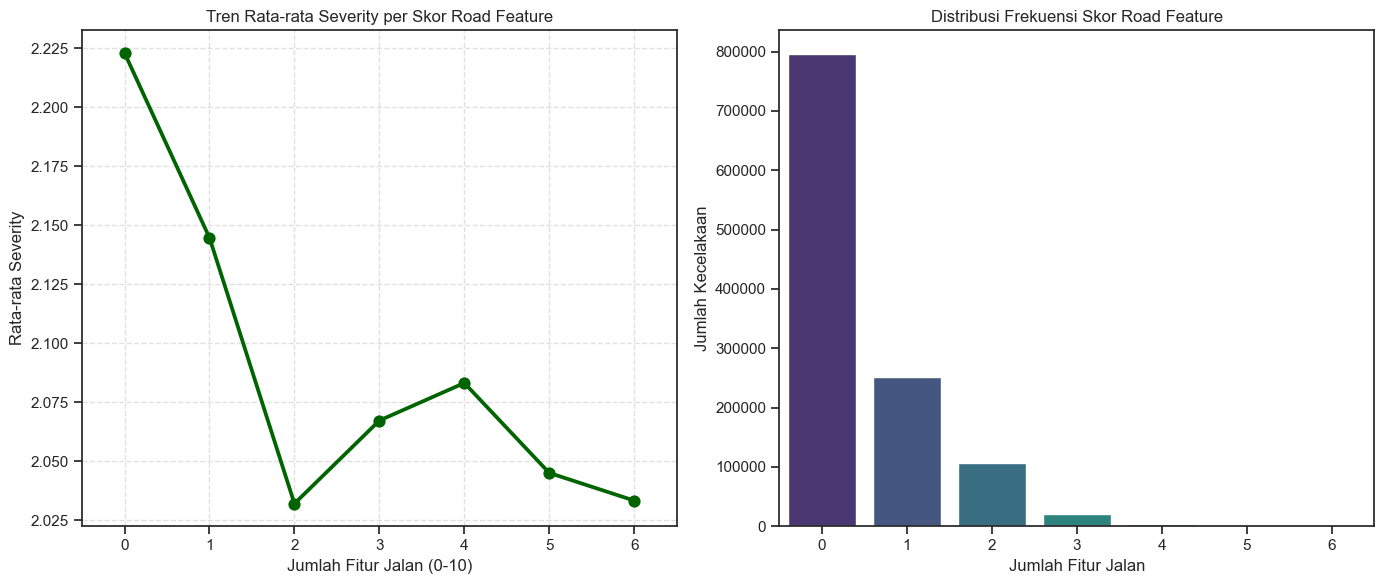

In [284]:
# Hubungan road_features dengan severity
road_impact = df.groupby('Road_Features')['Severity'].mean().reset_index()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.pointplot(data=road_impact, x='Road_Features', y='Severity', color='darkgreen')
plt.title('Tren Rata-rata Severity per Skor Road Feature')
plt.xlabel('Jumlah Fitur Jalan (0-10)')
plt.ylabel('Rata-rata Severity')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Road_Features', palette='viridis')
plt.title('Distribusi Frekuensi Skor Road Feature')
plt.xlabel('Jumlah Fitur Jalan')
plt.ylabel('Jumlah Kecelakaan')

plt.tight_layout()
plt.show()

# Hasil Akhir

In [286]:
df.shape

(1178913, 33)